In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
from tqdm import tqdm
import math
import glob
import uproot
import torch
from torch import nn, optim
import vector
import numpy as np
import torch.optim as optim
import awkward as ak
import itertools
import matplotlib
import matplotlib.pyplot as plt
from hepunits import units
from IPython.display import clear_output
import lightning as L
from lightning.pytorch import loggers as pl_loggers
import torch
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
import random
vector.register_awkward()

src_path = os.path.abspath('../src/')
print (src_path)
if src_path not in sys.path:
    sys.path.append(src_path)

from datasets import *
from models import *
from callbacks import *
from annealing import *
from constants import X0_VALUES
from distributions import *
from propagation import *
print (f"Running on GPU : {torch.cuda.is_available()}")
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
print (f"Accelerator : {accelerator}")
torch.set_float32_matmul_precision('medium')
import random
import optuna
from torch.utils.data import ConcatDataset
from matplotlib.colors import LogNorm
from Plot_functions import *
X0_VALUES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
C:\Users\shaiv\OneDrive\Desktop\MuonPropagation-Shaivya_shankar\MuonPropagation-Shaivya_shankar\src
Running on GPU : False
Accelerator : cpu


{'U': 3.166,
 'Pb': 5.612,
 'Fe': 17.57,
 'Al': 88.97,
 'Ca': 104.2,
 'SILICON_DIOXIDE': 122.89999999999999,
 'WATER': 360.79999999999995,
 'AIR': 303900.0}

In [4]:
data_paths = {
    'Pb': '../Data/Pb',
    'WATER': '../Data/water',
    'AIR': '../Data/Air',
    'SILICON_DIOXIDE': '../Data/SILICON_DIOXIDE'
}

# Define which transformations to use (all guarantee [-1, 1] range)
transformations_to_use = ['LogMinMax']

# This dictionary will hold the datasets, each with its own independent scaling
all_train_datasets = {}
all_valid_datasets = {}

print("--- Loading and Preparing Datasets with INDEPENDENT Scaling ---")

# Loop through each material
for material, path in data_paths.items():
    print(f"Processing material: {material}...")
    files = sorted(glob.glob(os.path.join(path, f'*{material}*.root')))
    
    if len(files) < 2:
        print(f"Warning: Not enough files for {material} to create a train/valid split. Skipping.")
        continue
    
    # Create arguments for the dataset
    args = {
        'position_vars': ['pos_x', 'pos_y', 'pos_z'],
        'position_unit': units.cm,
        'momentum_vars': ['p_x', 'p_y', 'p_z'],
        'momentum_unit': units.MeV,
        'initial_energy_var': 'initial_energy',
        'initial_energy_unit': units.GeV,
        'dtype': torch.float32,
        'X0': X0_VALUES[material],
        'transformations': transformations_to_use  # Specify transformations
    }
    
    # Create training dataset
    dataset_train = GANDataset_test(files=[files[0]], **args)
    
    # Create validation dataset with same transformations
    # (Each will fit its own scalers independently)
    dataset_valid = GANDataset_test(files=[files[1]], **args)
    
    print(f"Scaling for {material} has been established from its own data.")
    
    # Store the independently scaled datasets
    all_train_datasets[material] = dataset_train
    all_valid_datasets[material] = dataset_valid

# Create combined datasets and loaders
if all_train_datasets:
    combined_train_dataset = ConcatDataset(list(all_train_datasets.values()))
    combined_valid_dataset = ConcatDataset(list(all_valid_datasets.values()))
    
    batch_size = 10000
    loader_train = DataLoader(
        dataset=combined_train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )
    loader_valid = DataLoader(
        dataset=combined_valid_dataset,
        batch_size=batch_size,
        shuffle=False,
    )
    
    print("\n--- Data Loading Complete ---")
    print(f"Total combined training samples: {len(combined_train_dataset)}")
    print(f"Total combined validation samples: {len(combined_valid_dataset)}")
    print("Note: Each material has independent scaling - this is intentional for your use case.")
else:
    print("\nCould not load data from any material.")

--- Loading and Preparing Datasets with INDEPENDENT Scaling ---
Processing material: Pb...


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997990 [99.999%]


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997988 [99.999%]
Scaling for Pb has been established from its own data.
Processing material: WATER...


...

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1993925 steps, selecting 1993250 [99.966%]
Scaling for AIR has been established from its own data.
Processing material: SILICON_DIOXIDE...


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997990 [99.999%]


Files:   0%|          | 0/1 [00:00<?, ?it/s]

Concatenating arrays
... done
Producing 3D position vector
2000 * var * Vector3D[
    x: float64,
    y: float64,
    z: float64
]
Producing 3D momentum vector
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
2000 * var * Momentum3D[
    px: float64,
    py: float64,
    pz: float64
]
Out of 1998000 steps, selecting 1997987 [99.999%]
Scaling for SILICON_DIOXIDE has been established from its own data.

--- Data Loading Complete ---
Total combined training samples: 7985339
Total combined validation samples: 7985178
Note: Each material has independent scaling - this is intentional for your use case.


# 2 D correlation Plot


--- Generating 2D Correlation Plots from Loaded Scaled Data ---
Condition features: ['P', 'X0']
Target features: ['-dP', 'dtheta', 'dr']

Generating 2D plots for: Original
    Original data ranges: x=[1.01e-07, 9.06], y=[1.49e-08, 0.118]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Original data ranges: x=[1.01e-07, 9.06], y=[6.67e-06, 0.0561]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Original data ranges: x=[1.49e-08, 0.118], y=[6.67e-06, 0.0561]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Original data ranges: x=[0.528, 499], y=[1.01e-07, 9.06]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Original data ranges: x=[0.528, 499], y=[1.49e-08, 0.118]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Original data ranges: x=[0.528, 499], y=[6.67e-06, 0.0561]
✓ Plotted Pb - $P$ vs $\Delta r$
    Original data ranges: x=[1.38e-05, 60.6], y=[1.49e-08, 2.31]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Original data ranges: x=[1.38e-05, 60.6], y=[2.99e-05, 3.61]
✓ Plotted WATER - $-\Delta P

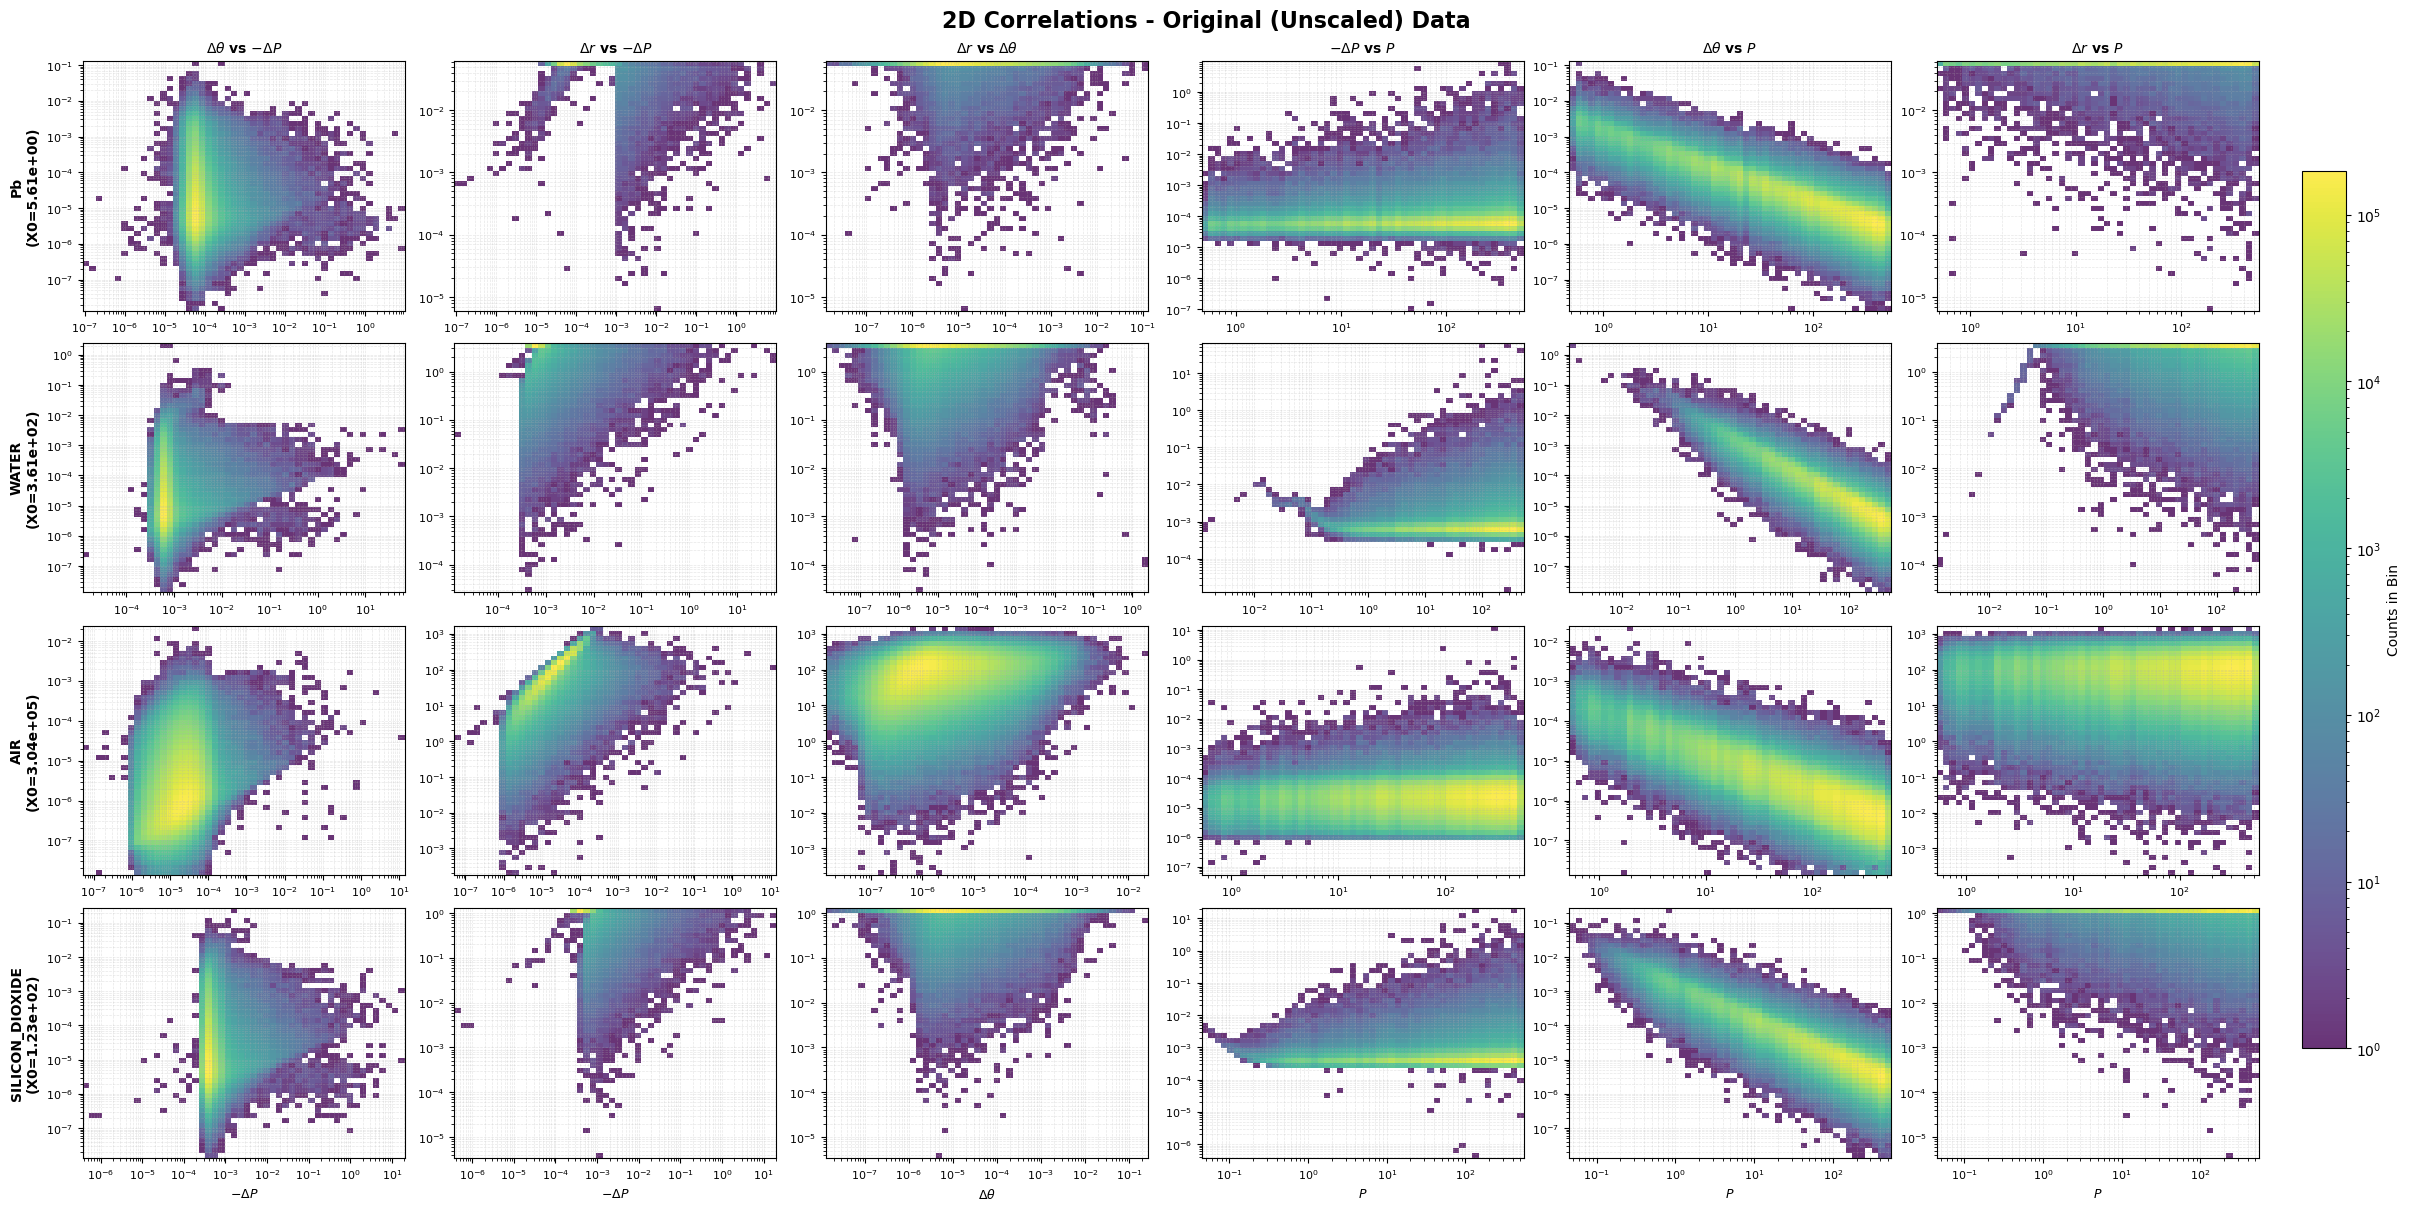


Generating 2D plots for: MinMax
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=

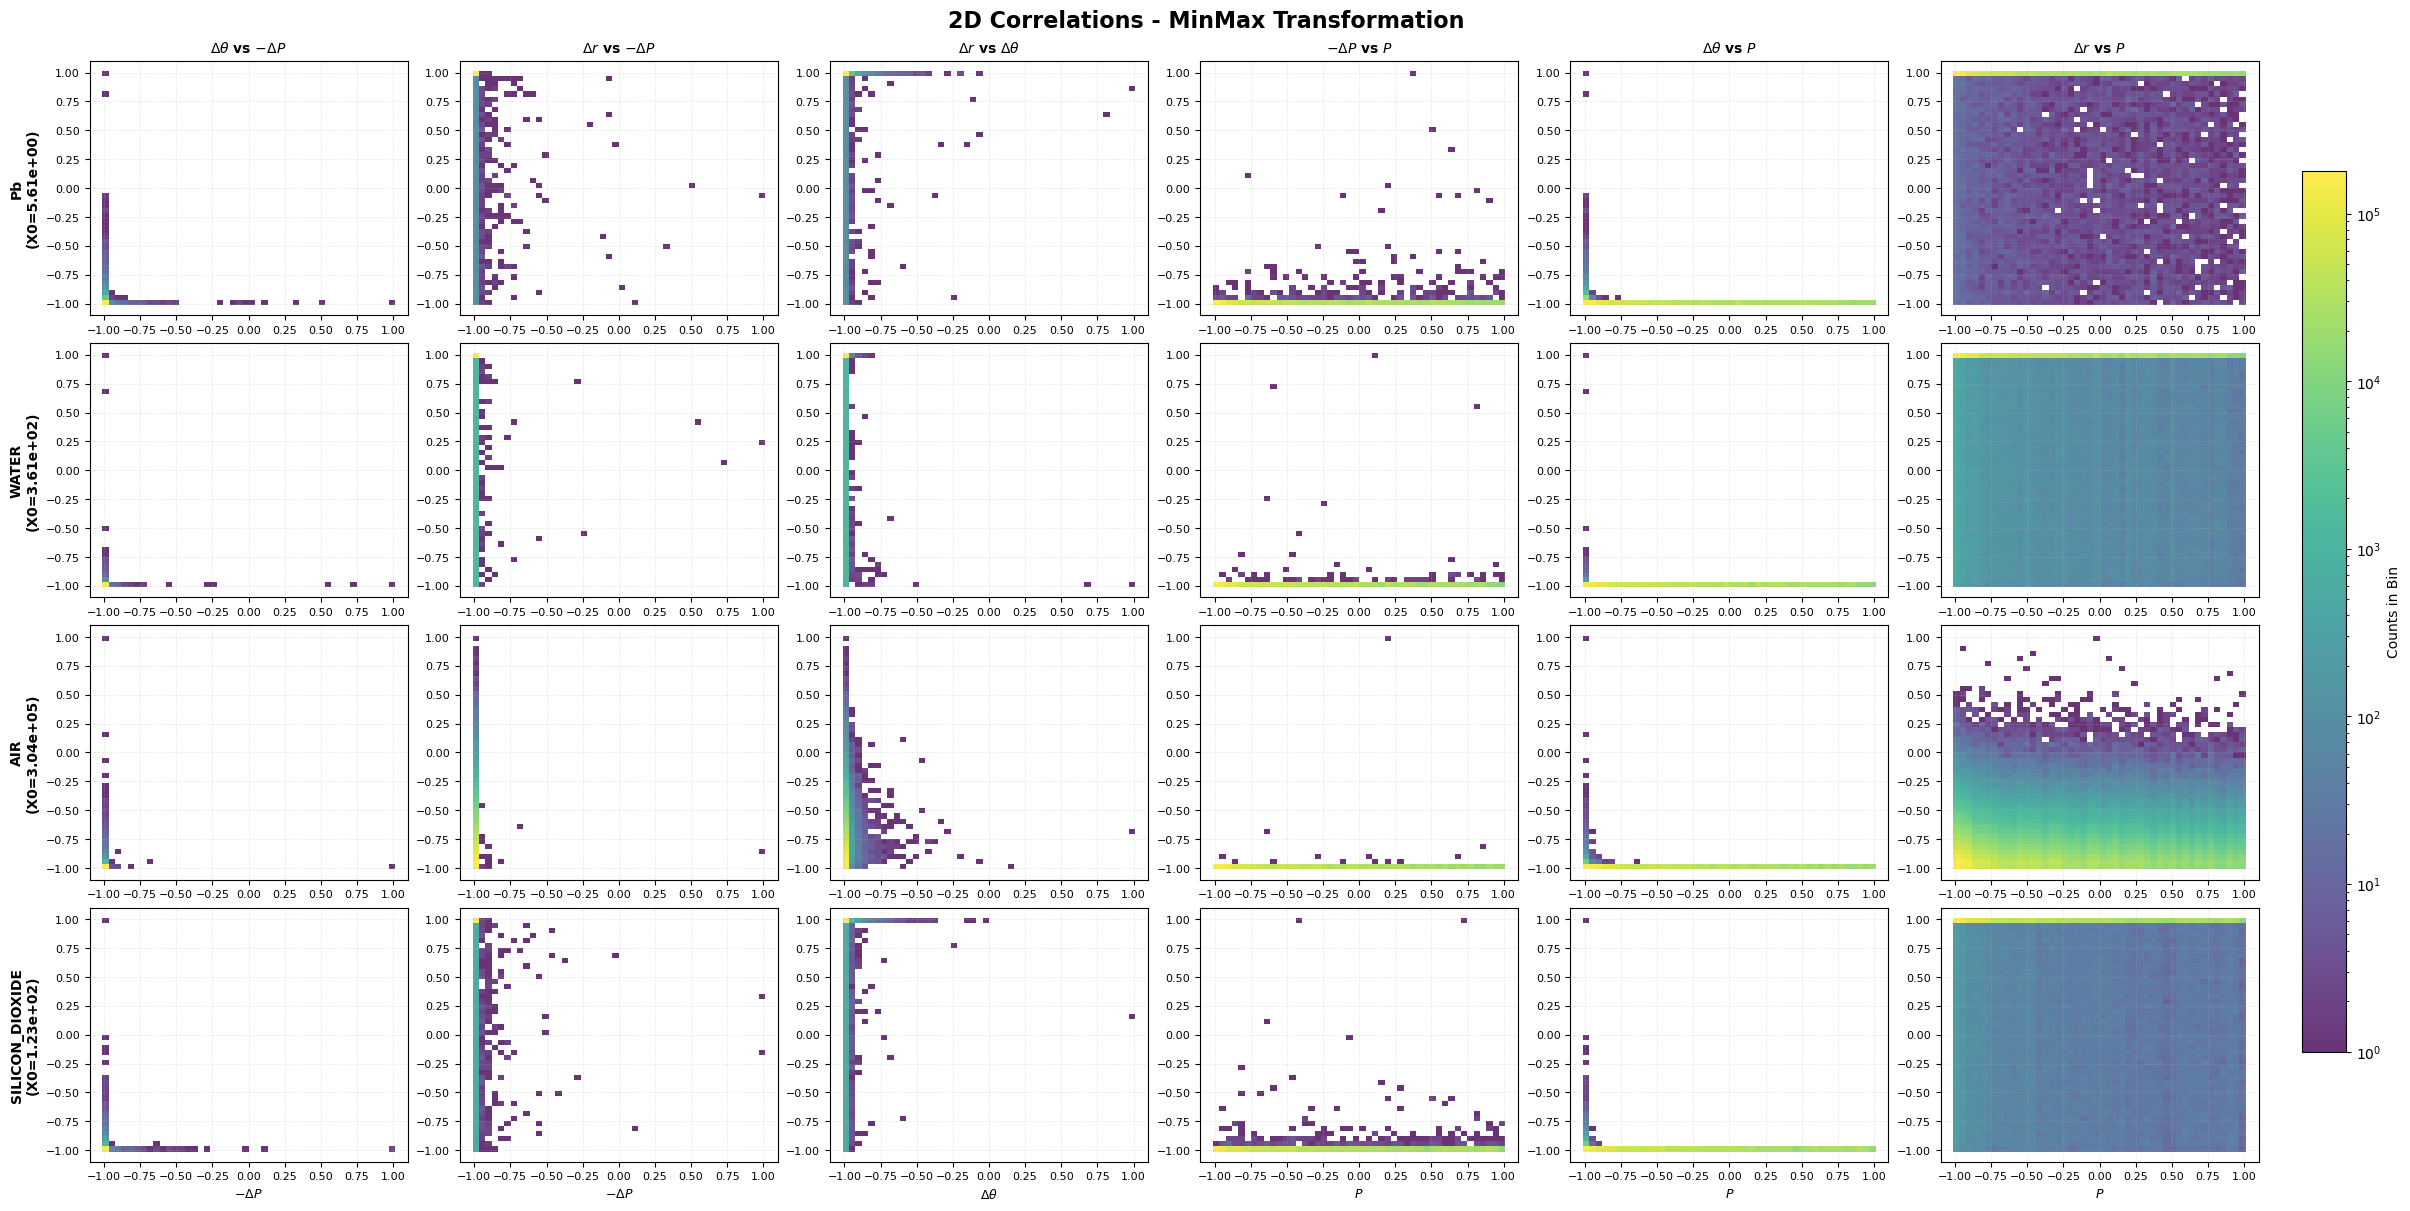


Generating 2D plots for: LogMinMax
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000],

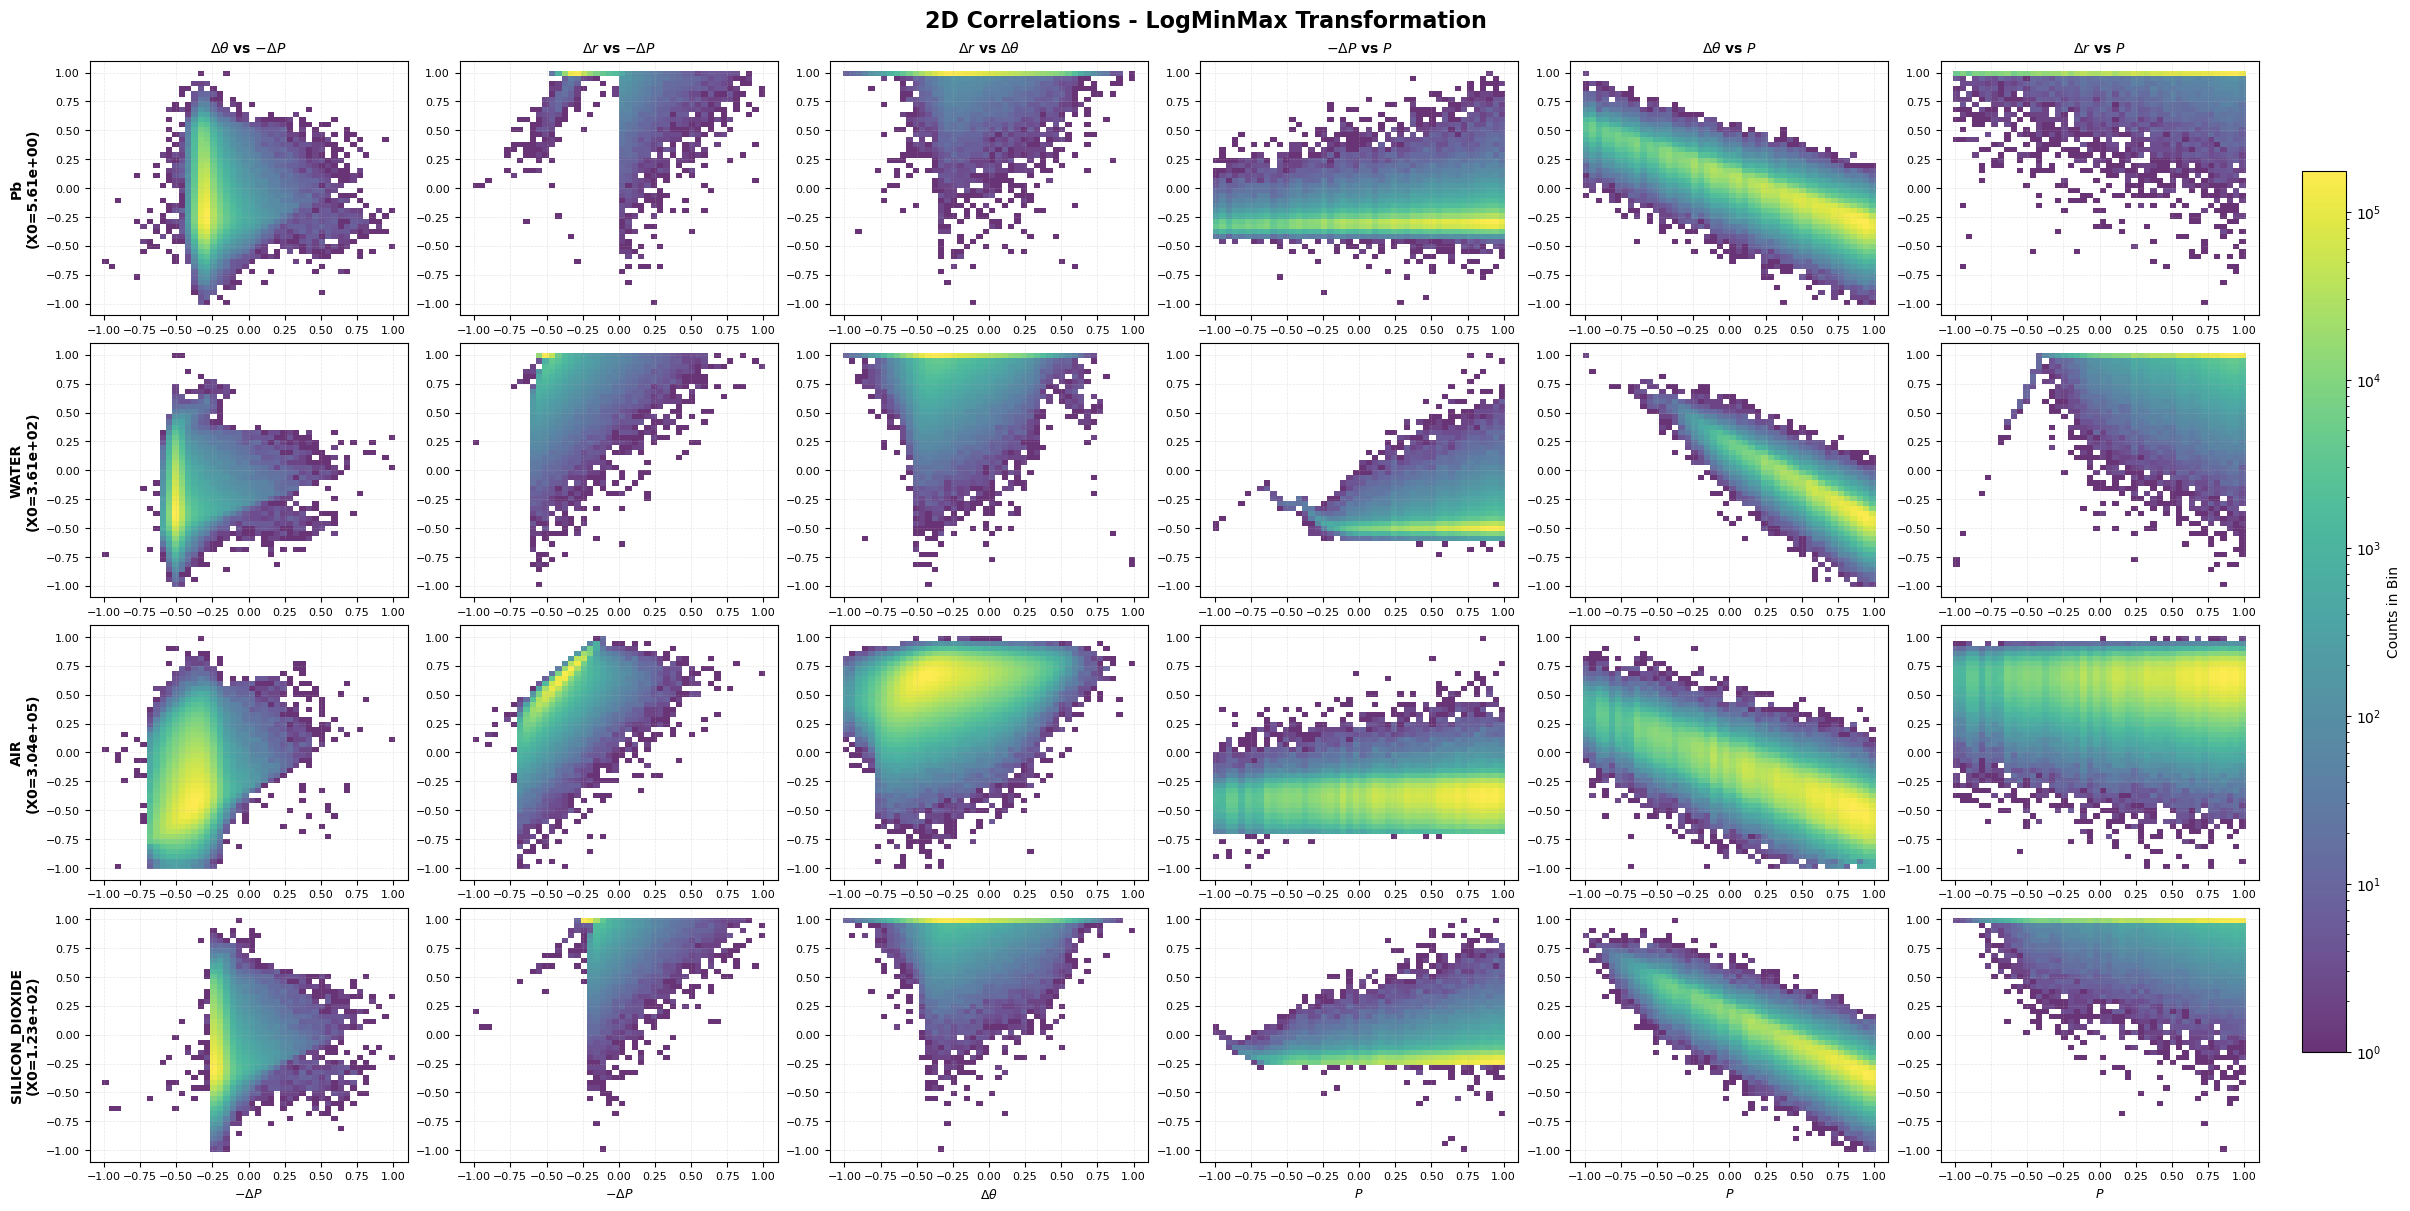


Generating 2D plots for: LogStandardMinMax
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000,

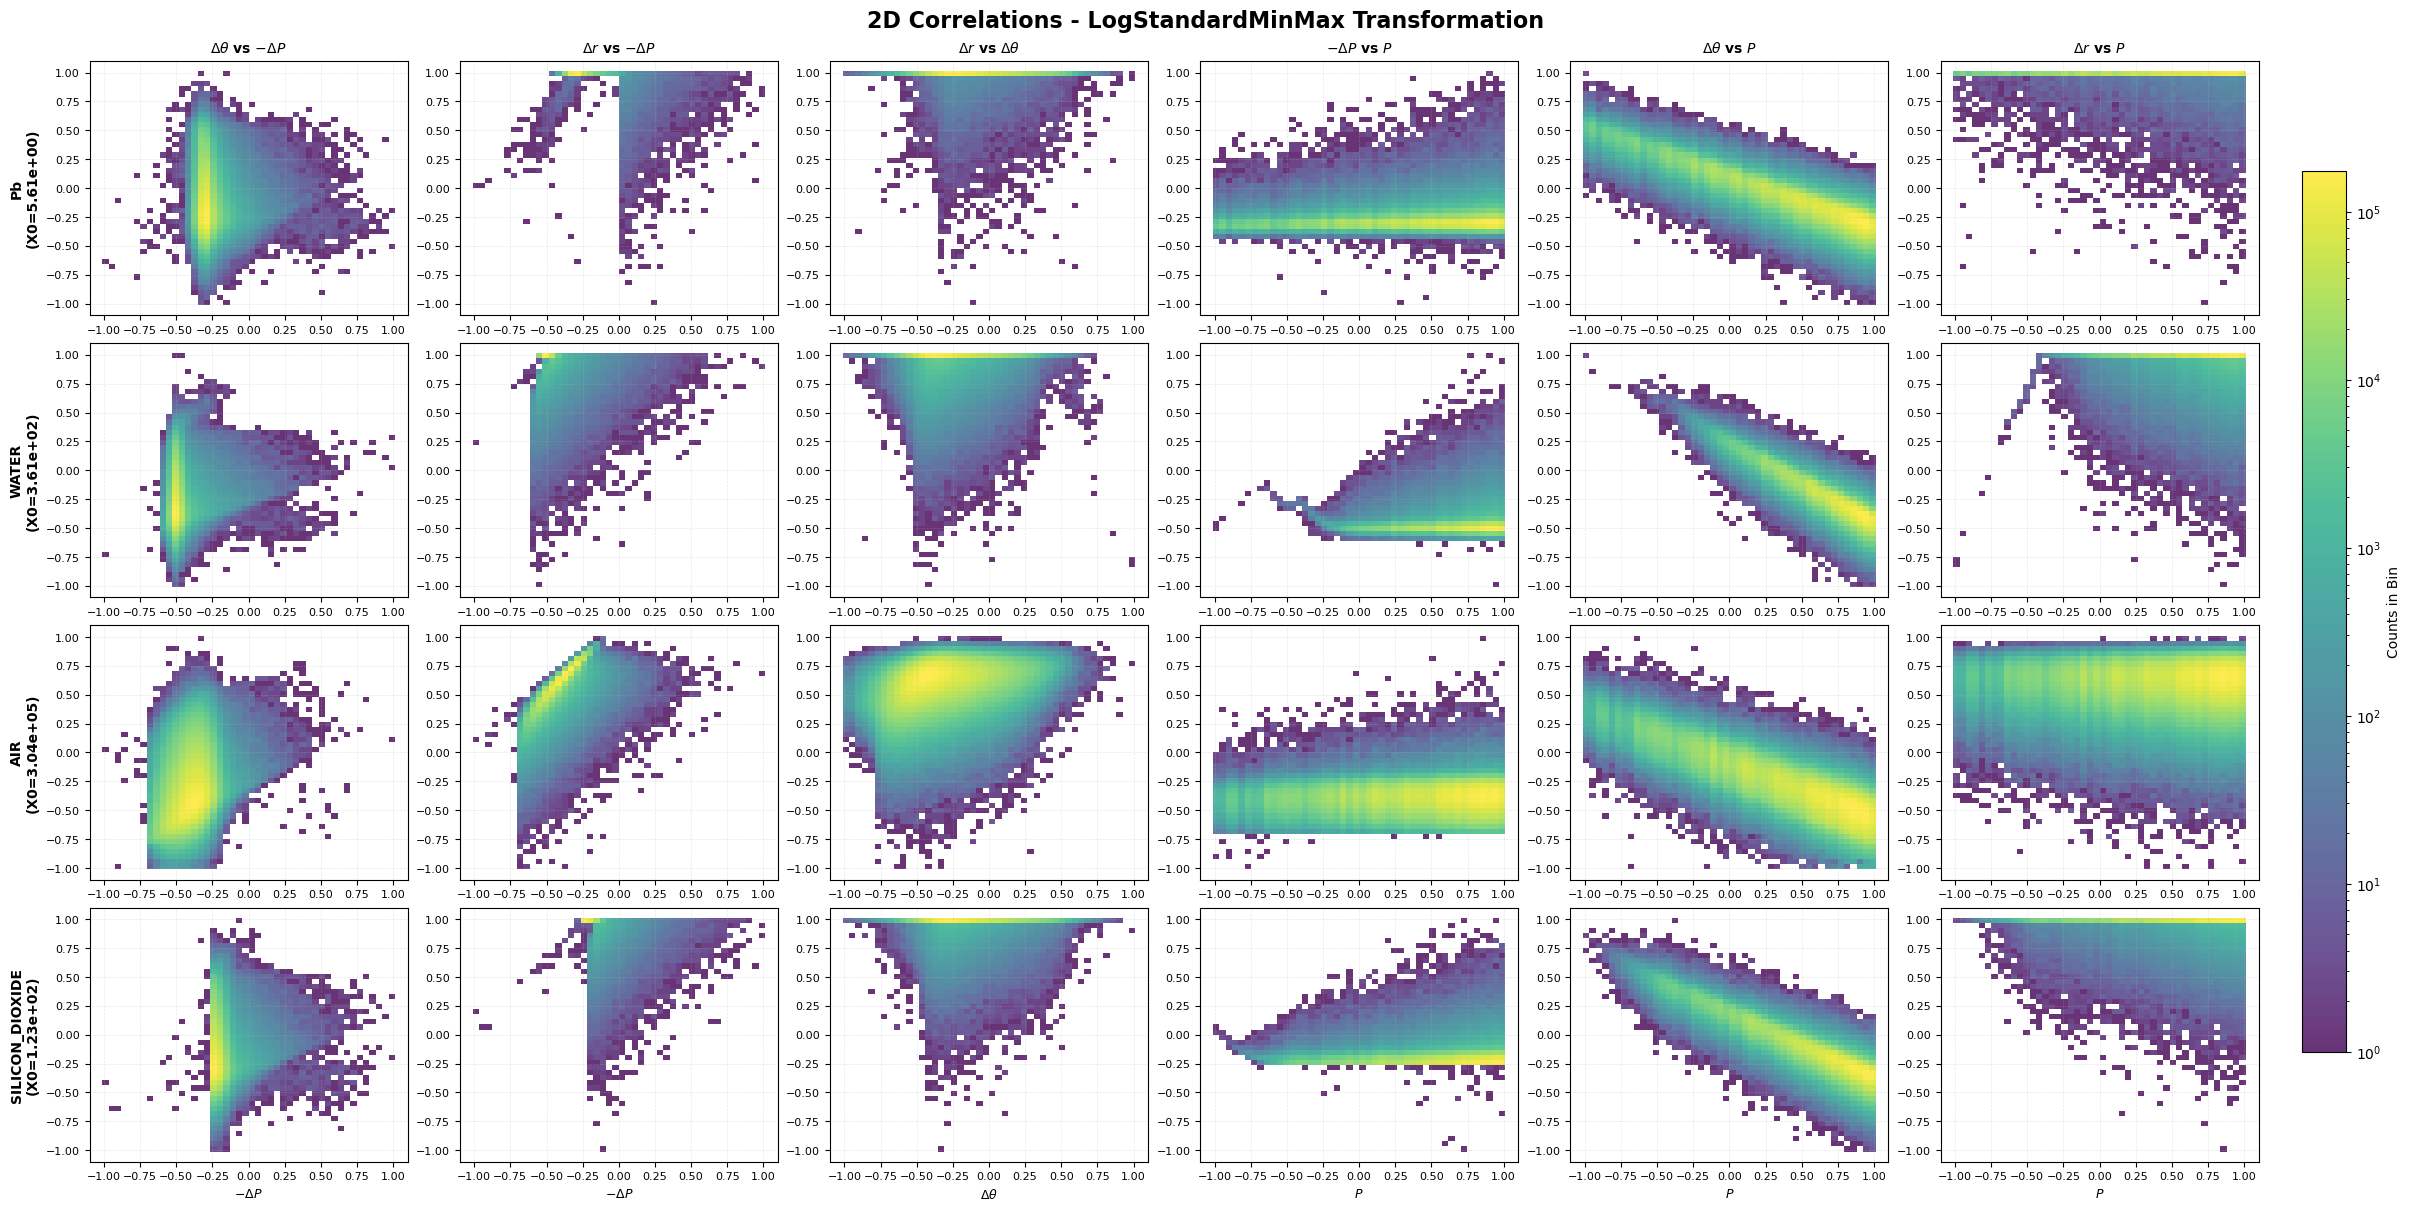


Generating 2D plots for: Tanh
    Scaled data ranges: x=[-0.013, 1.000], y=[-0.224, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.013, 1.000], y=[-1.000, 0.058]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.224, 1.000], y=[-1.000, 0.058]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.818, 0.975], y=[-0.013, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-0.818, 0.975], y=[-0.224, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.818, 0.975], y=[-1.000, 0.058]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-0.014, 1.000], y=[-0.046, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.014, 1.000], y=[-1.000, 0.289]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.046, 1.000], y=[-1.000, 0.289]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.826, 0.980], y=[-

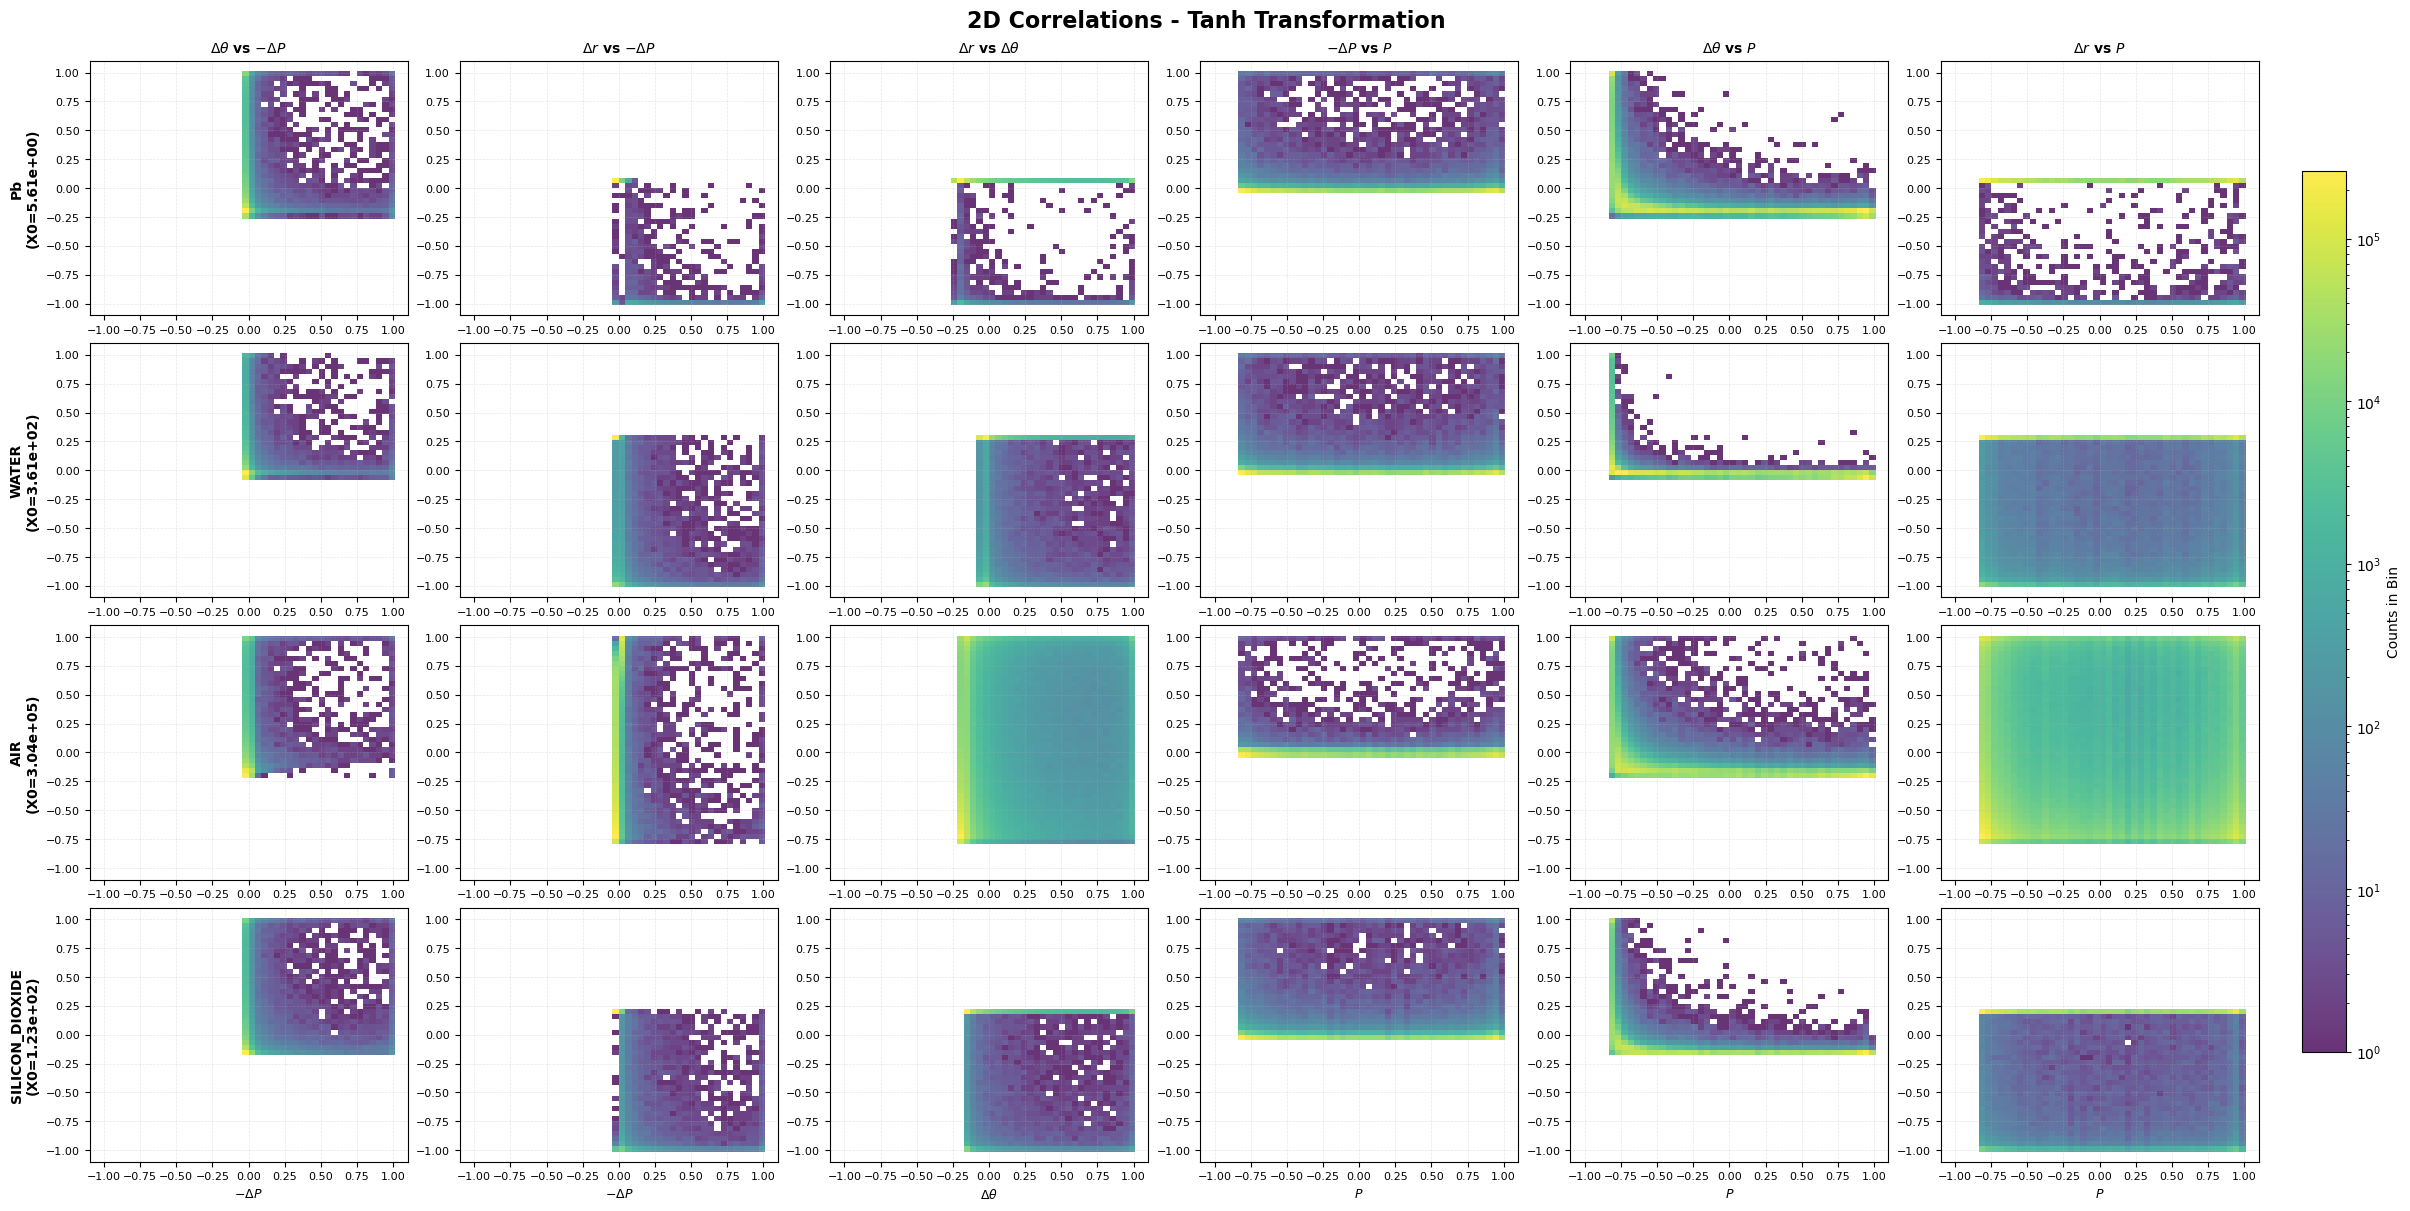


Generating 2D plots for: Sigmoid
    Scaled data ranges: x=[-0.007, 1.000], y=[-0.114, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.007, 1.000], y=[-1.000, 0.029]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.114, 1.000], y=[-1.000, 0.029]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.519, 0.800], y=[-0.007, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-0.519, 0.800], y=[-0.114, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.519, 0.800], y=[-1.000, 0.029]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-0.007, 1.000], y=[-0.023, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.007, 1.000], y=[-0.988, 0.148]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.023, 1.000], y=[-0.988, 0.148]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.528, 0.816], y

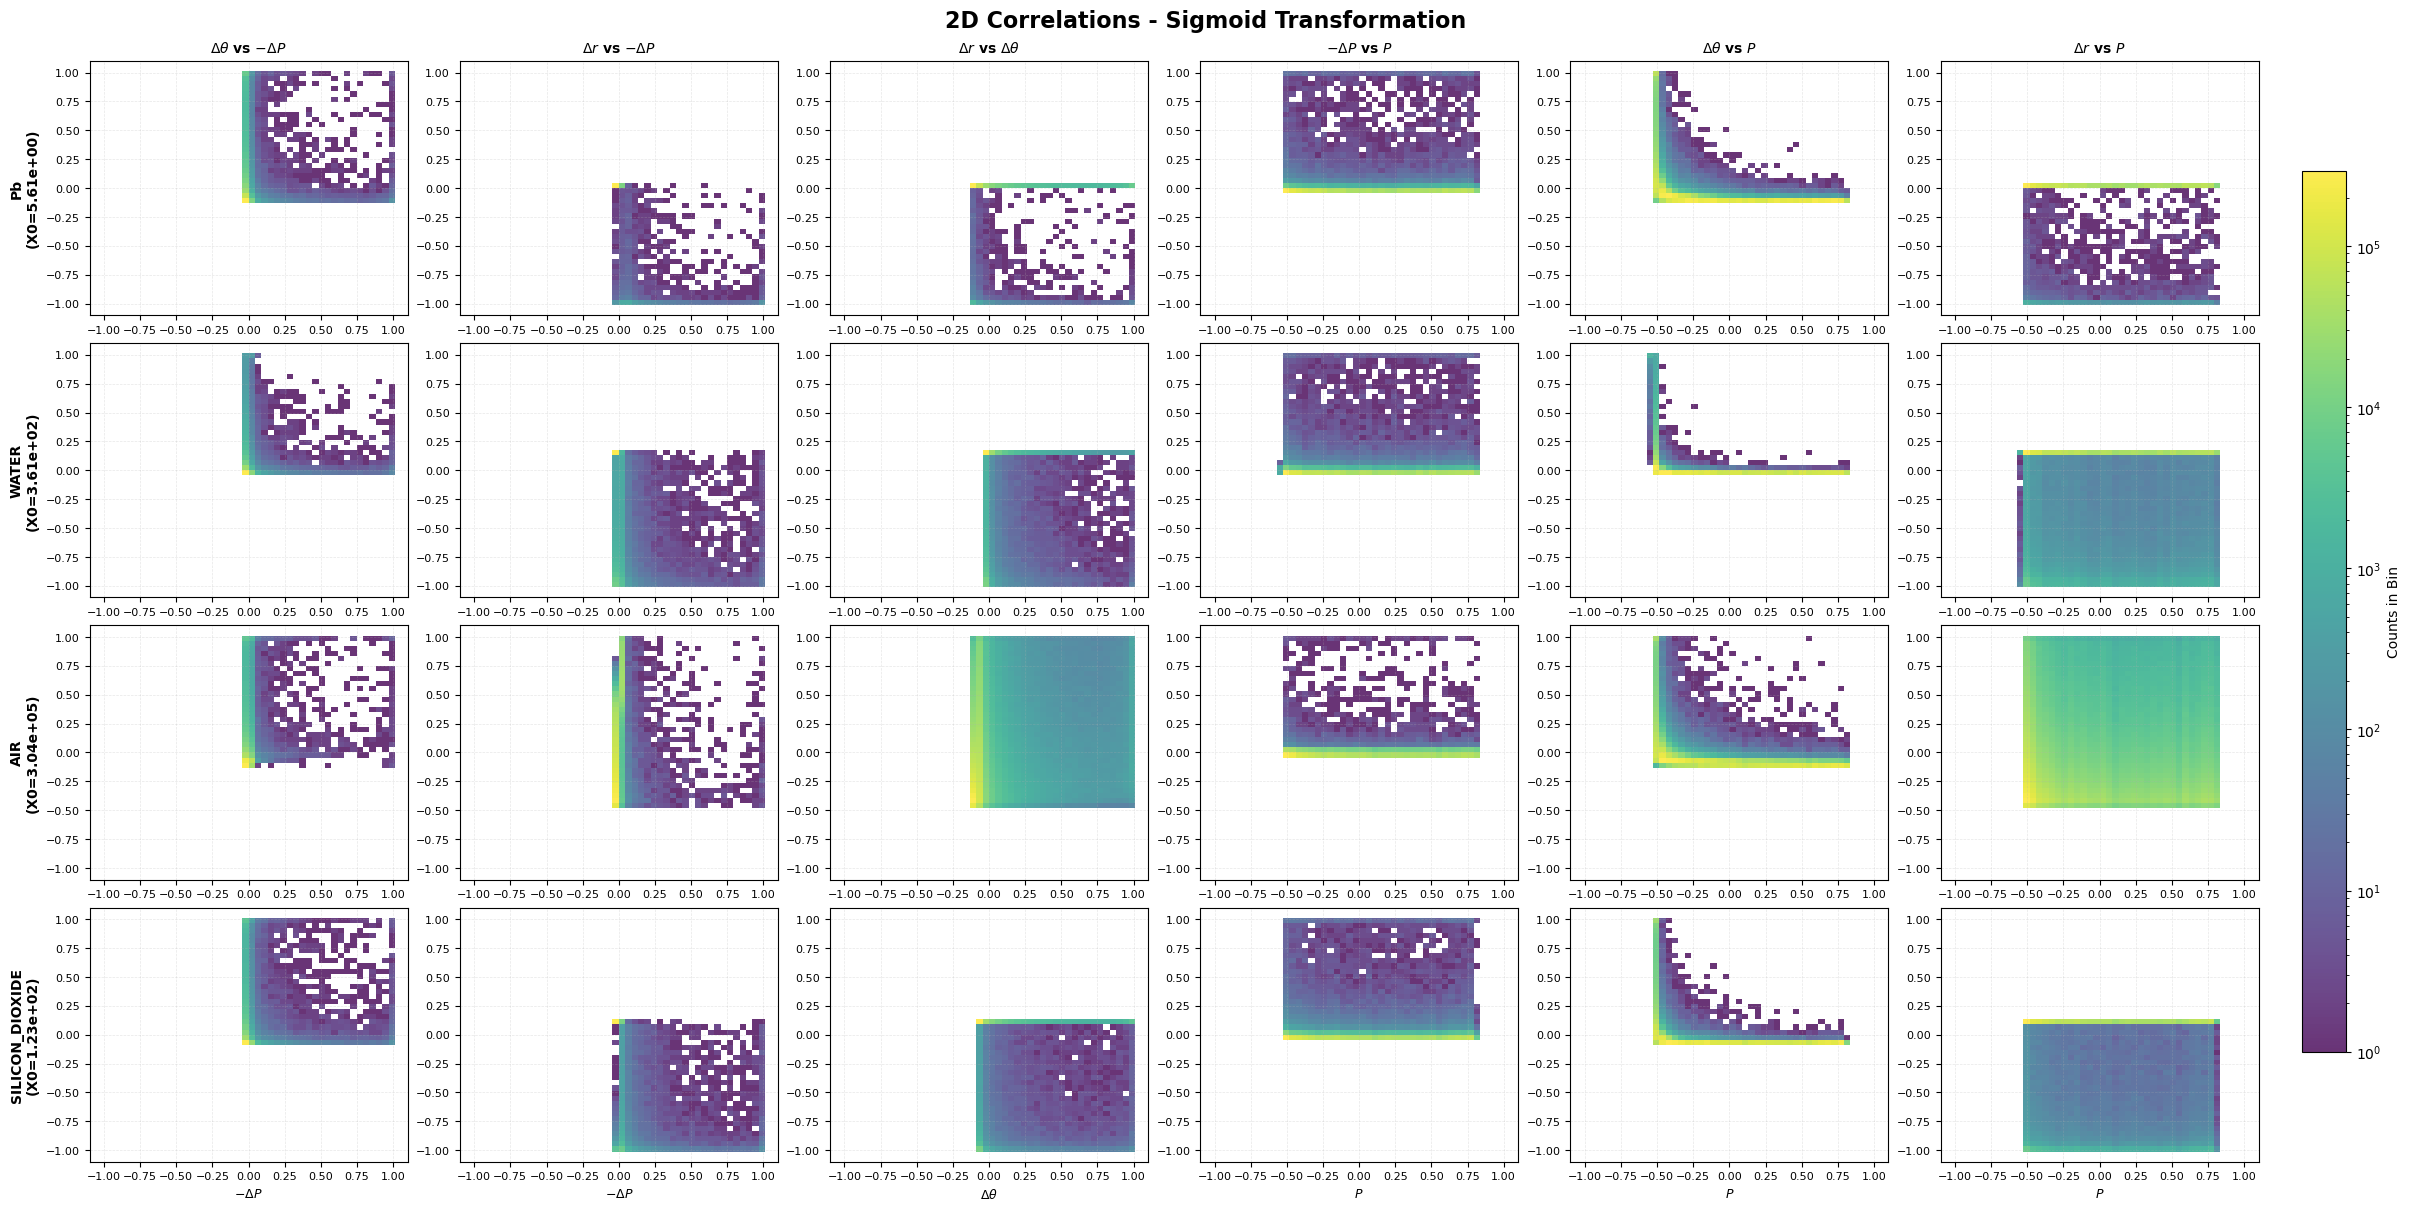


Generating 2D plots for: LinearScale
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 1.000]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000

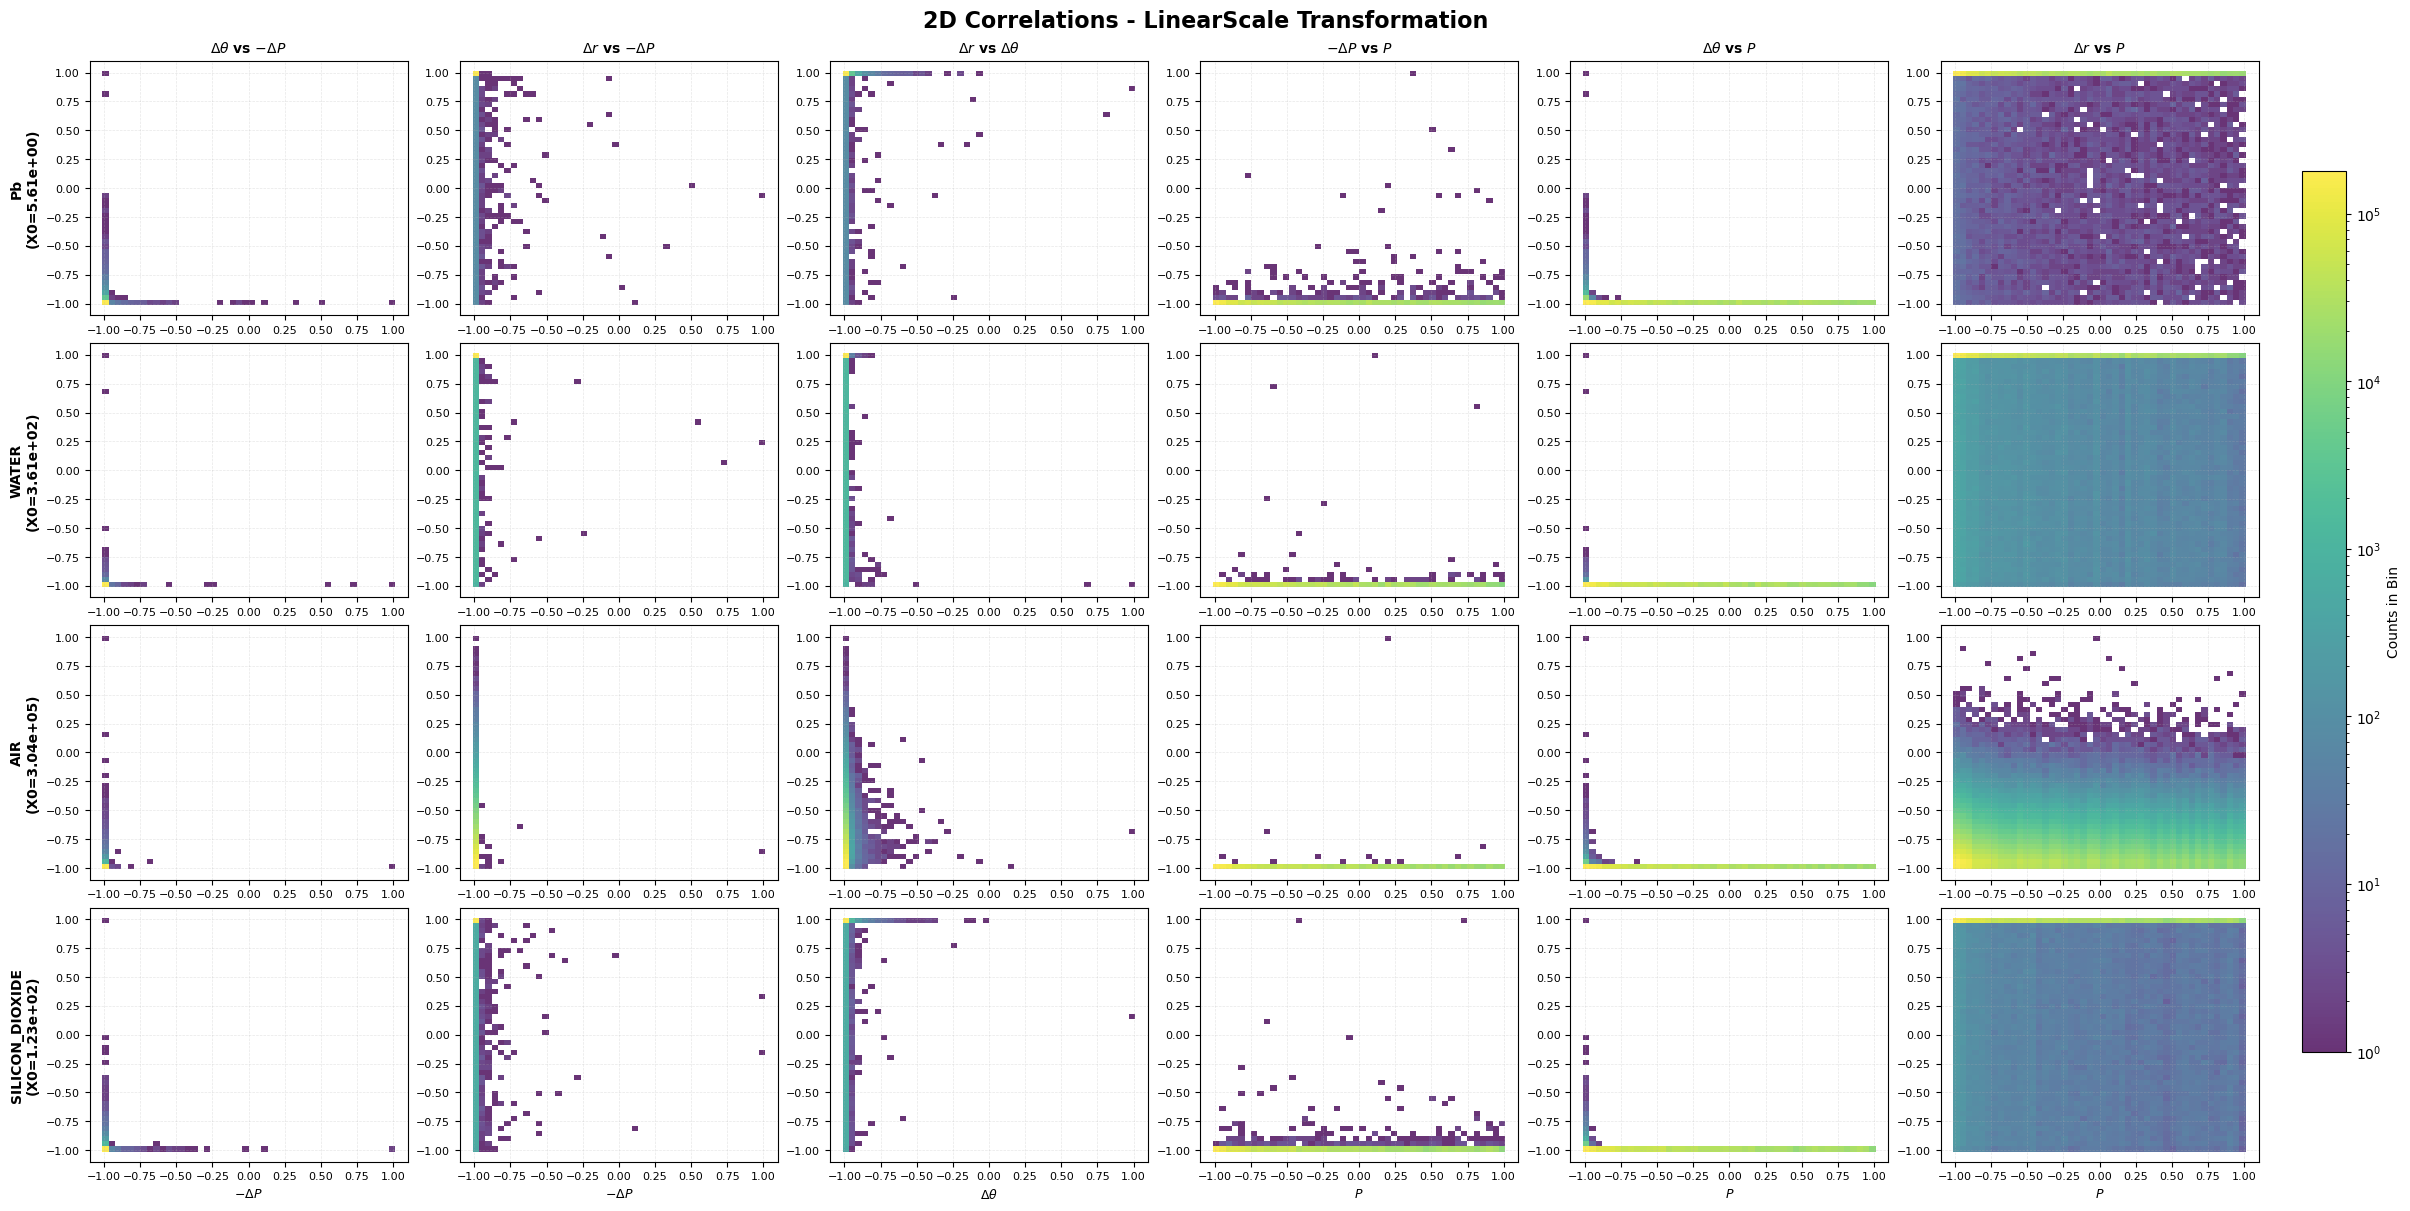


Generating 2D plots for: LogTanh
    Scaled data ranges: x=[-1.000, 1.000], y=[-0.999, 1.000]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 0.047]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.999, 1.000], y=[-1.000, 0.047]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.997, 0.818], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-0.997, 0.818], y=[-0.999, 1.000]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.997, 0.818], y=[-1.000, 0.047]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-0.999, 1.000]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 0.236]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.999, 1.000], y=[-1.000, 0.236]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 0.819], y

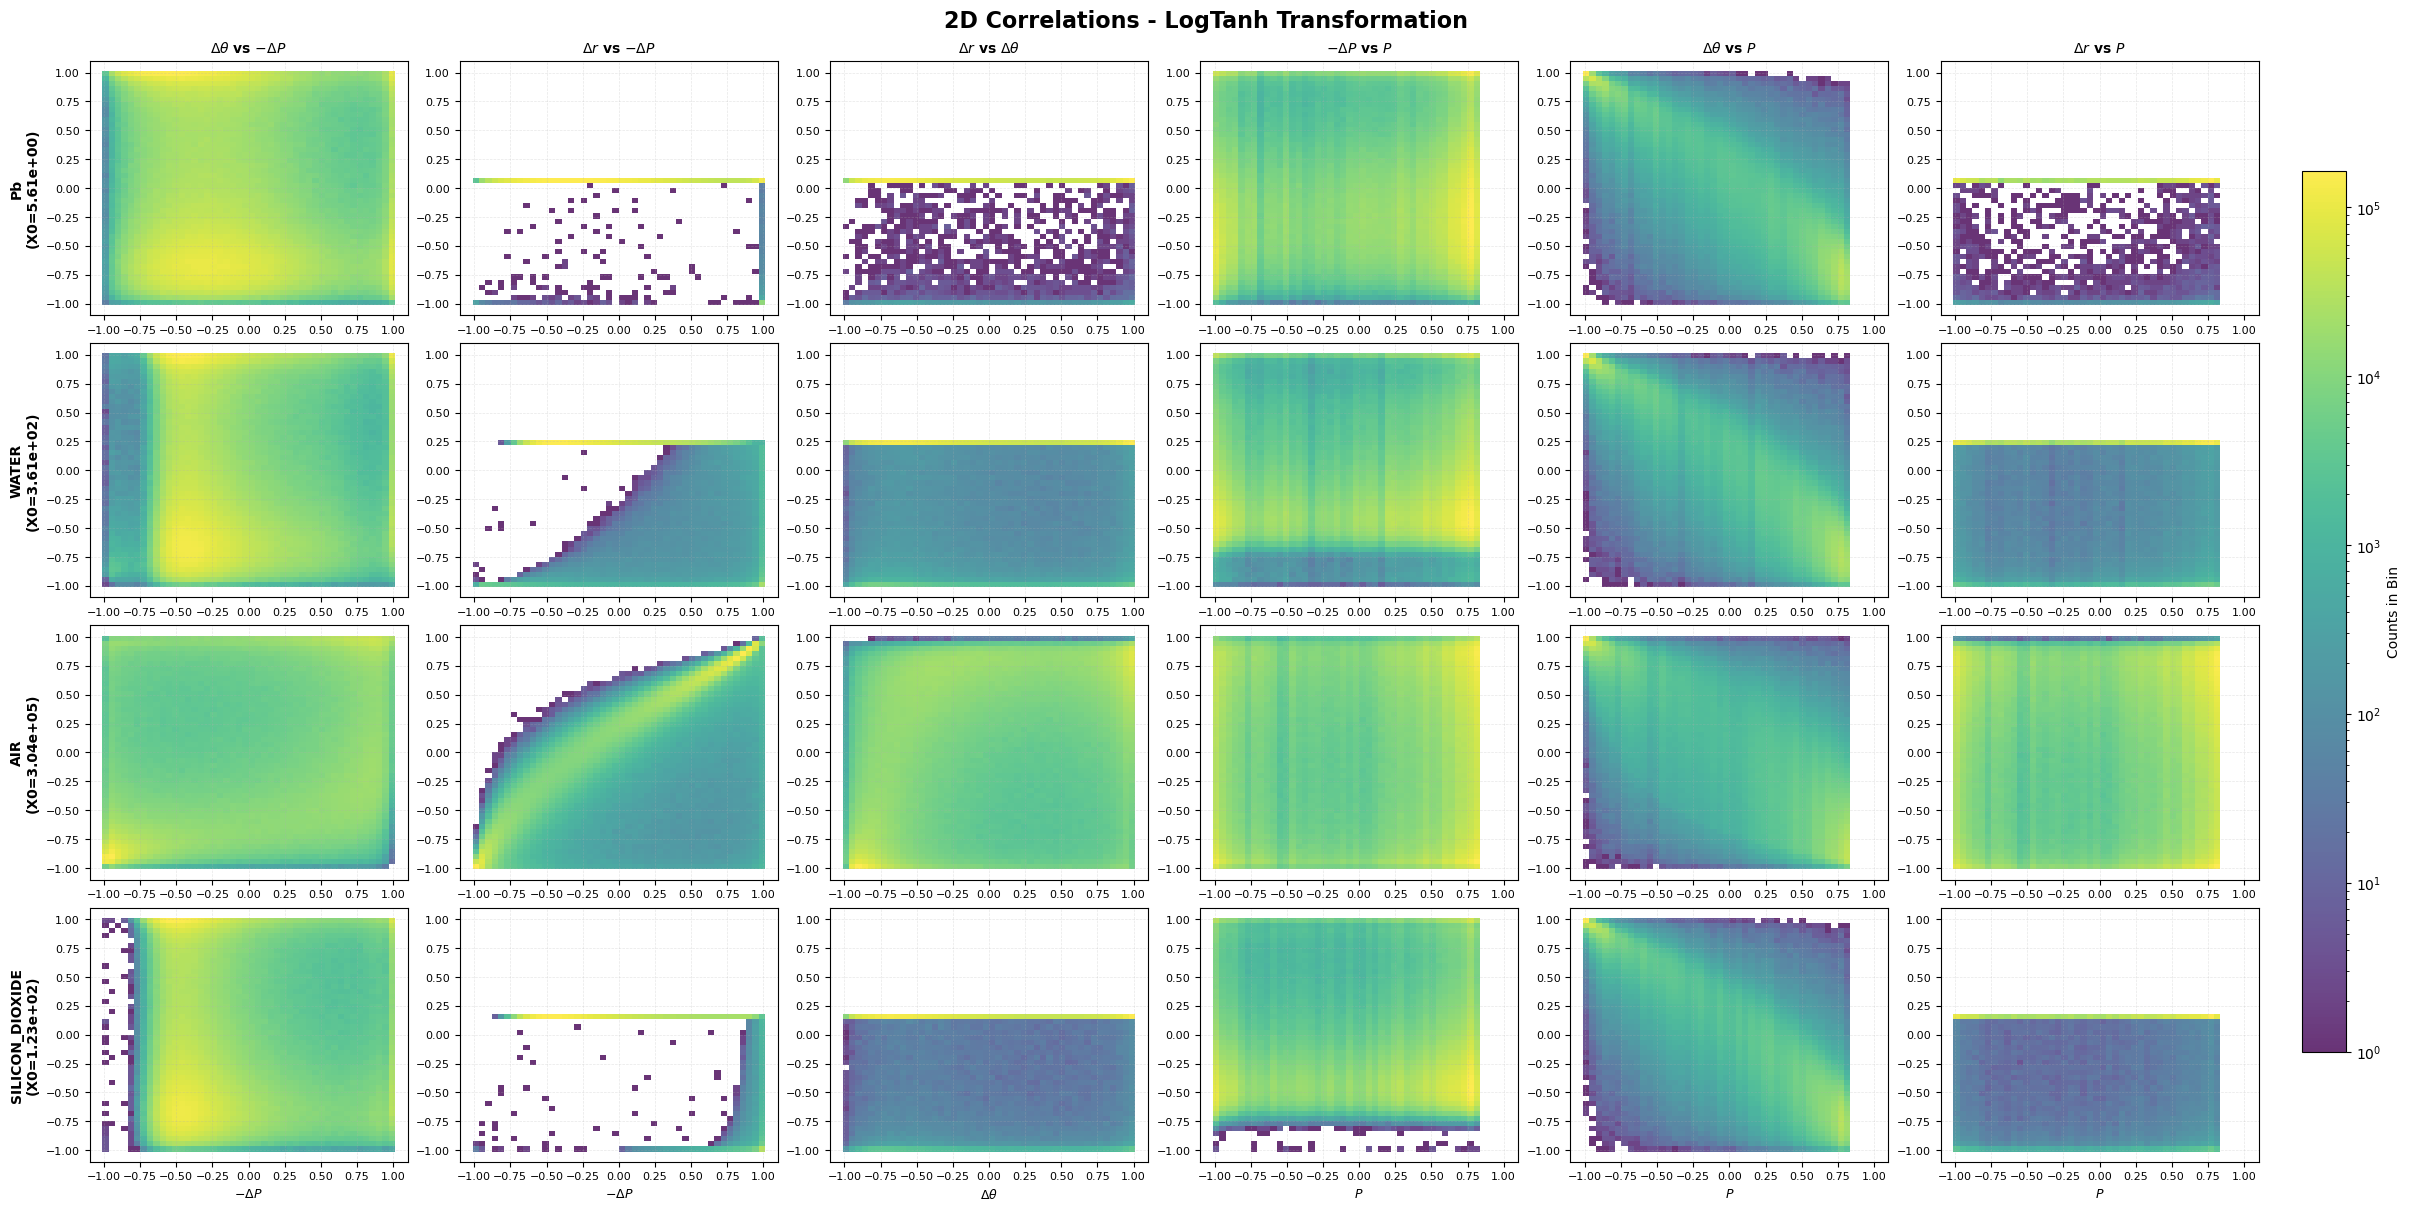


Generating 2D plots for: LogSigmoid
    Scaled data ranges: x=[-1.000, 1.000], y=[-0.967, 0.990]
✓ Plotted Pb - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 0.023]
✓ Plotted Pb - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.967, 0.990], y=[-1.000, 0.023]
✓ Plotted Pb - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.928, 0.519], y=[-1.000, 1.000]
✓ Plotted Pb - $P$ vs $-\Delta P$
    Scaled data ranges: x=[-0.928, 0.519], y=[-0.967, 0.990]
✓ Plotted Pb - $P$ vs $\Delta\theta$
    Scaled data ranges: x=[-0.928, 0.519], y=[-1.000, 0.023]
✓ Plotted Pb - $P$ vs $\Delta r$
    Scaled data ranges: x=[-1.000, 1.000], y=[-0.966, 0.998]
✓ Plotted WATER - $-\Delta P$ vs $\Delta\theta$
    Scaled data ranges: x=[-1.000, 1.000], y=[-1.000, 0.120]
✓ Plotted WATER - $-\Delta P$ vs $\Delta r$
    Scaled data ranges: x=[-0.966, 0.998], y=[-1.000, 0.120]
✓ Plotted WATER - $\Delta\theta$ vs $\Delta r$
    Scaled data ranges: x=[-0.999, 0.521]

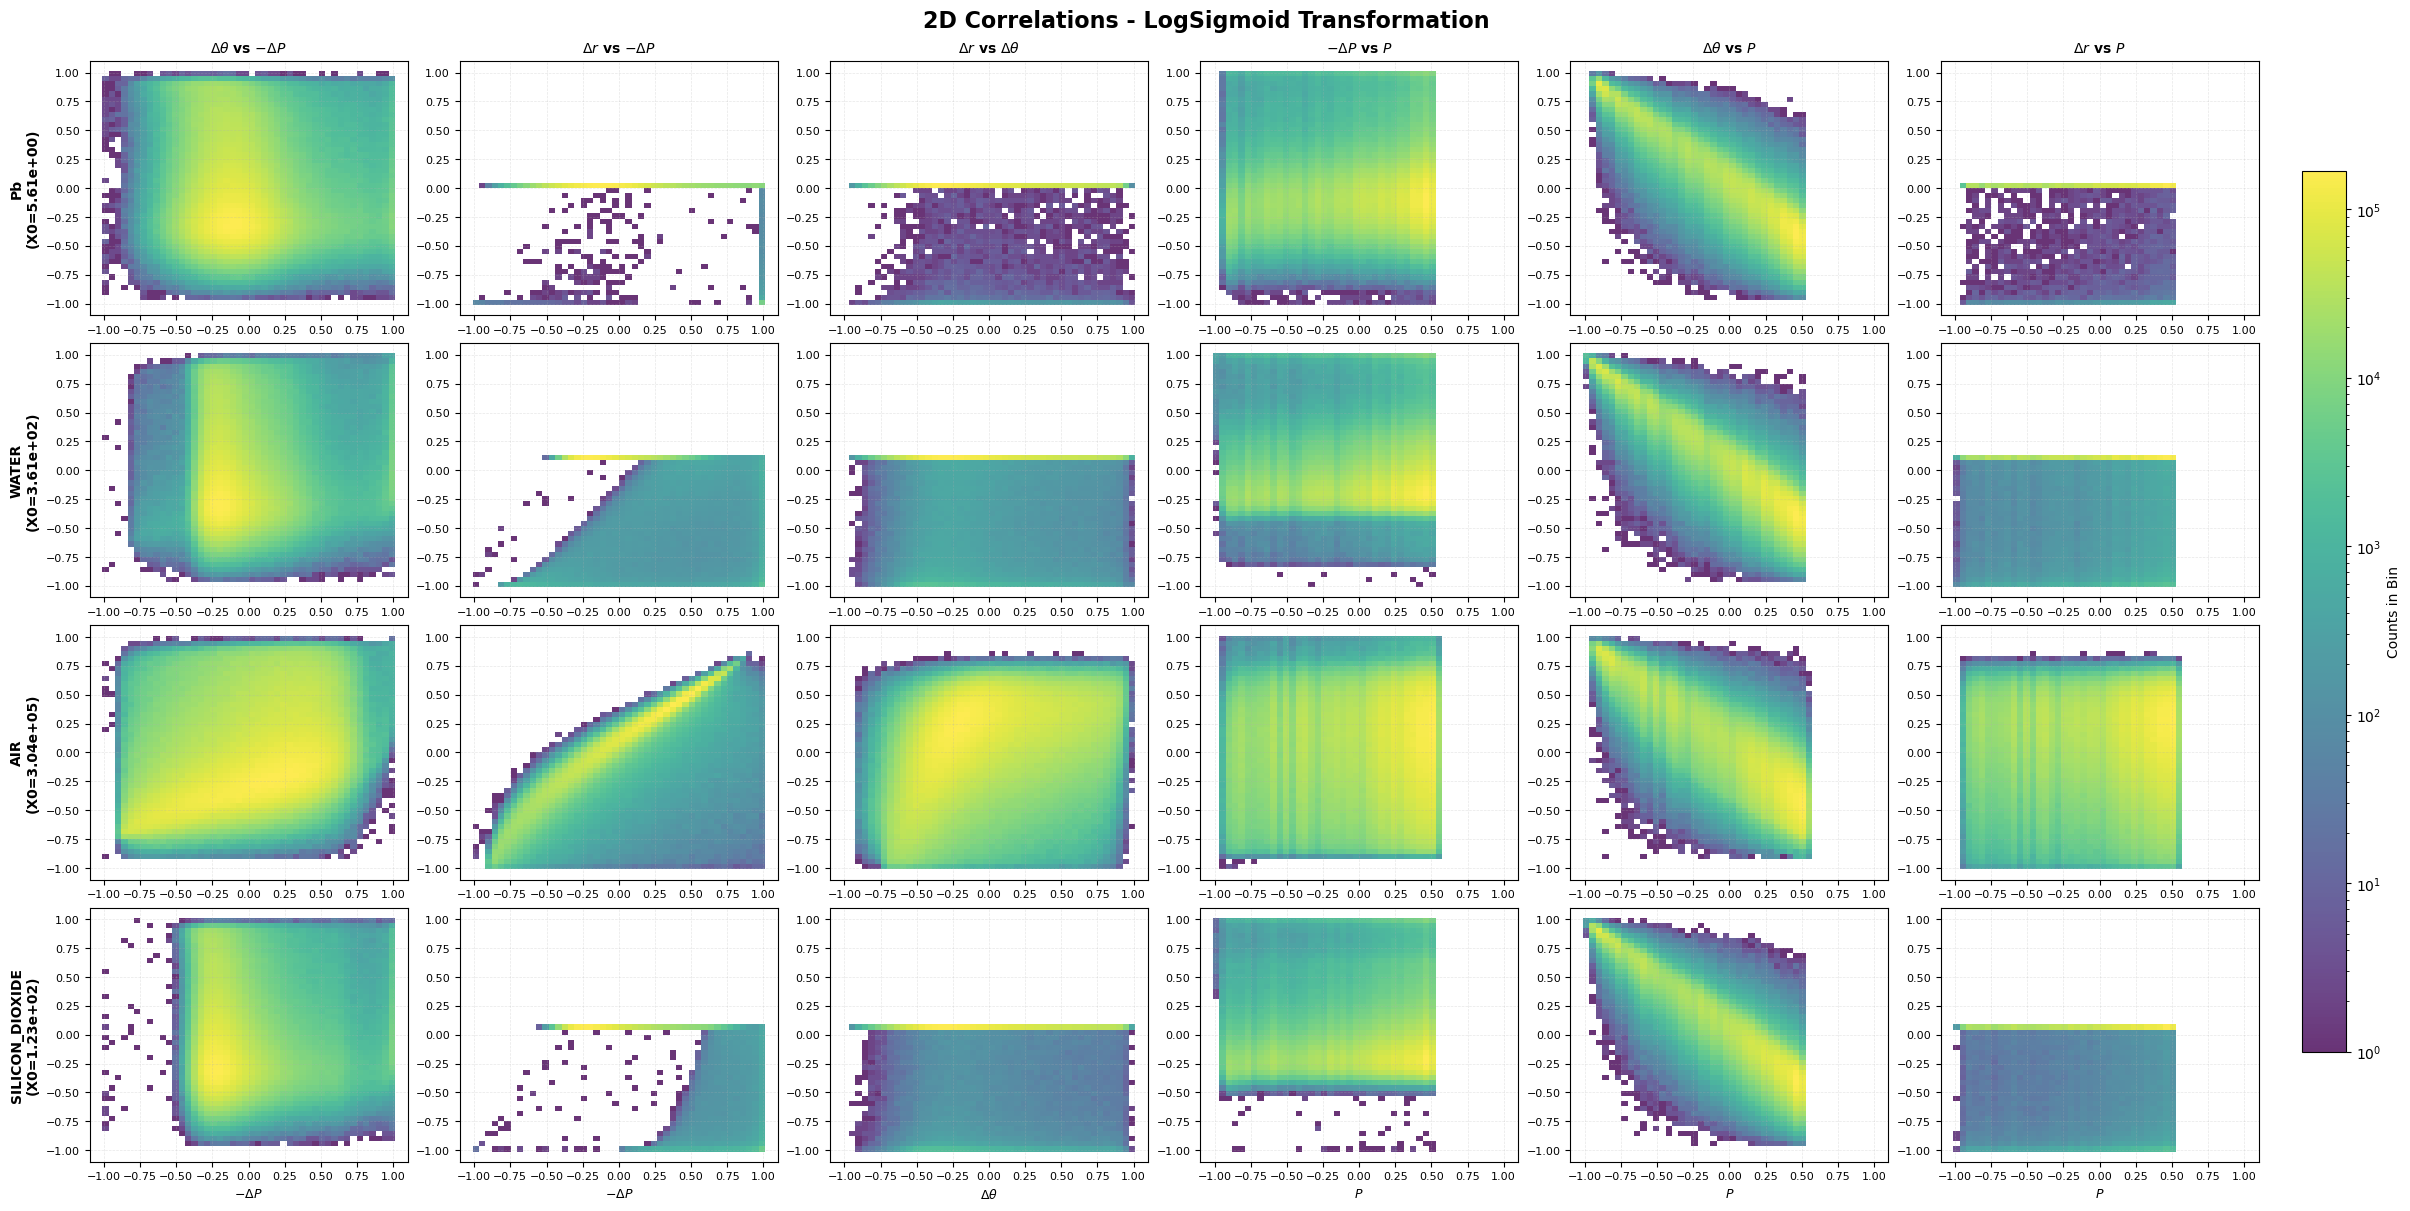


--- All 2D correlation plots completed ---


In [6]:
plot_2d_correlations_by_transformation(
    all_datasets=all_train_datasets,
    X0_values=X0_VALUES
)

# 1D plot


--- Preparing to Generate Distribution Plots with Larger Scaled Data Plot ---
--- Generating plots for ORIGINAL (physical scale) data ---


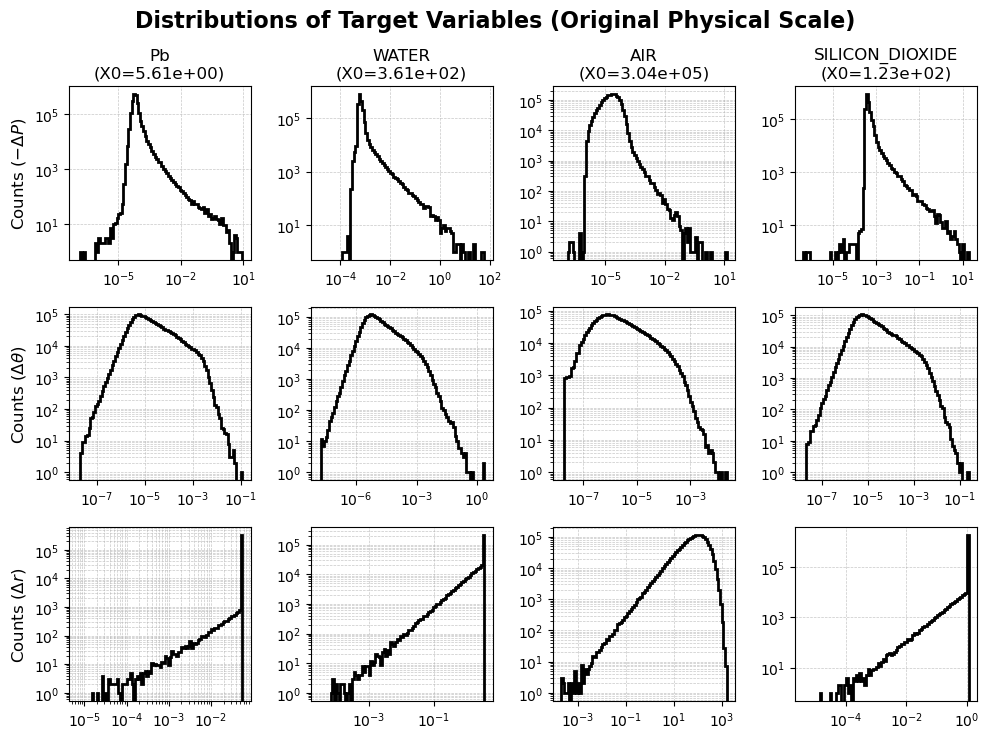


--- Generating plots for PREPROCESSED data with LARGER size ---


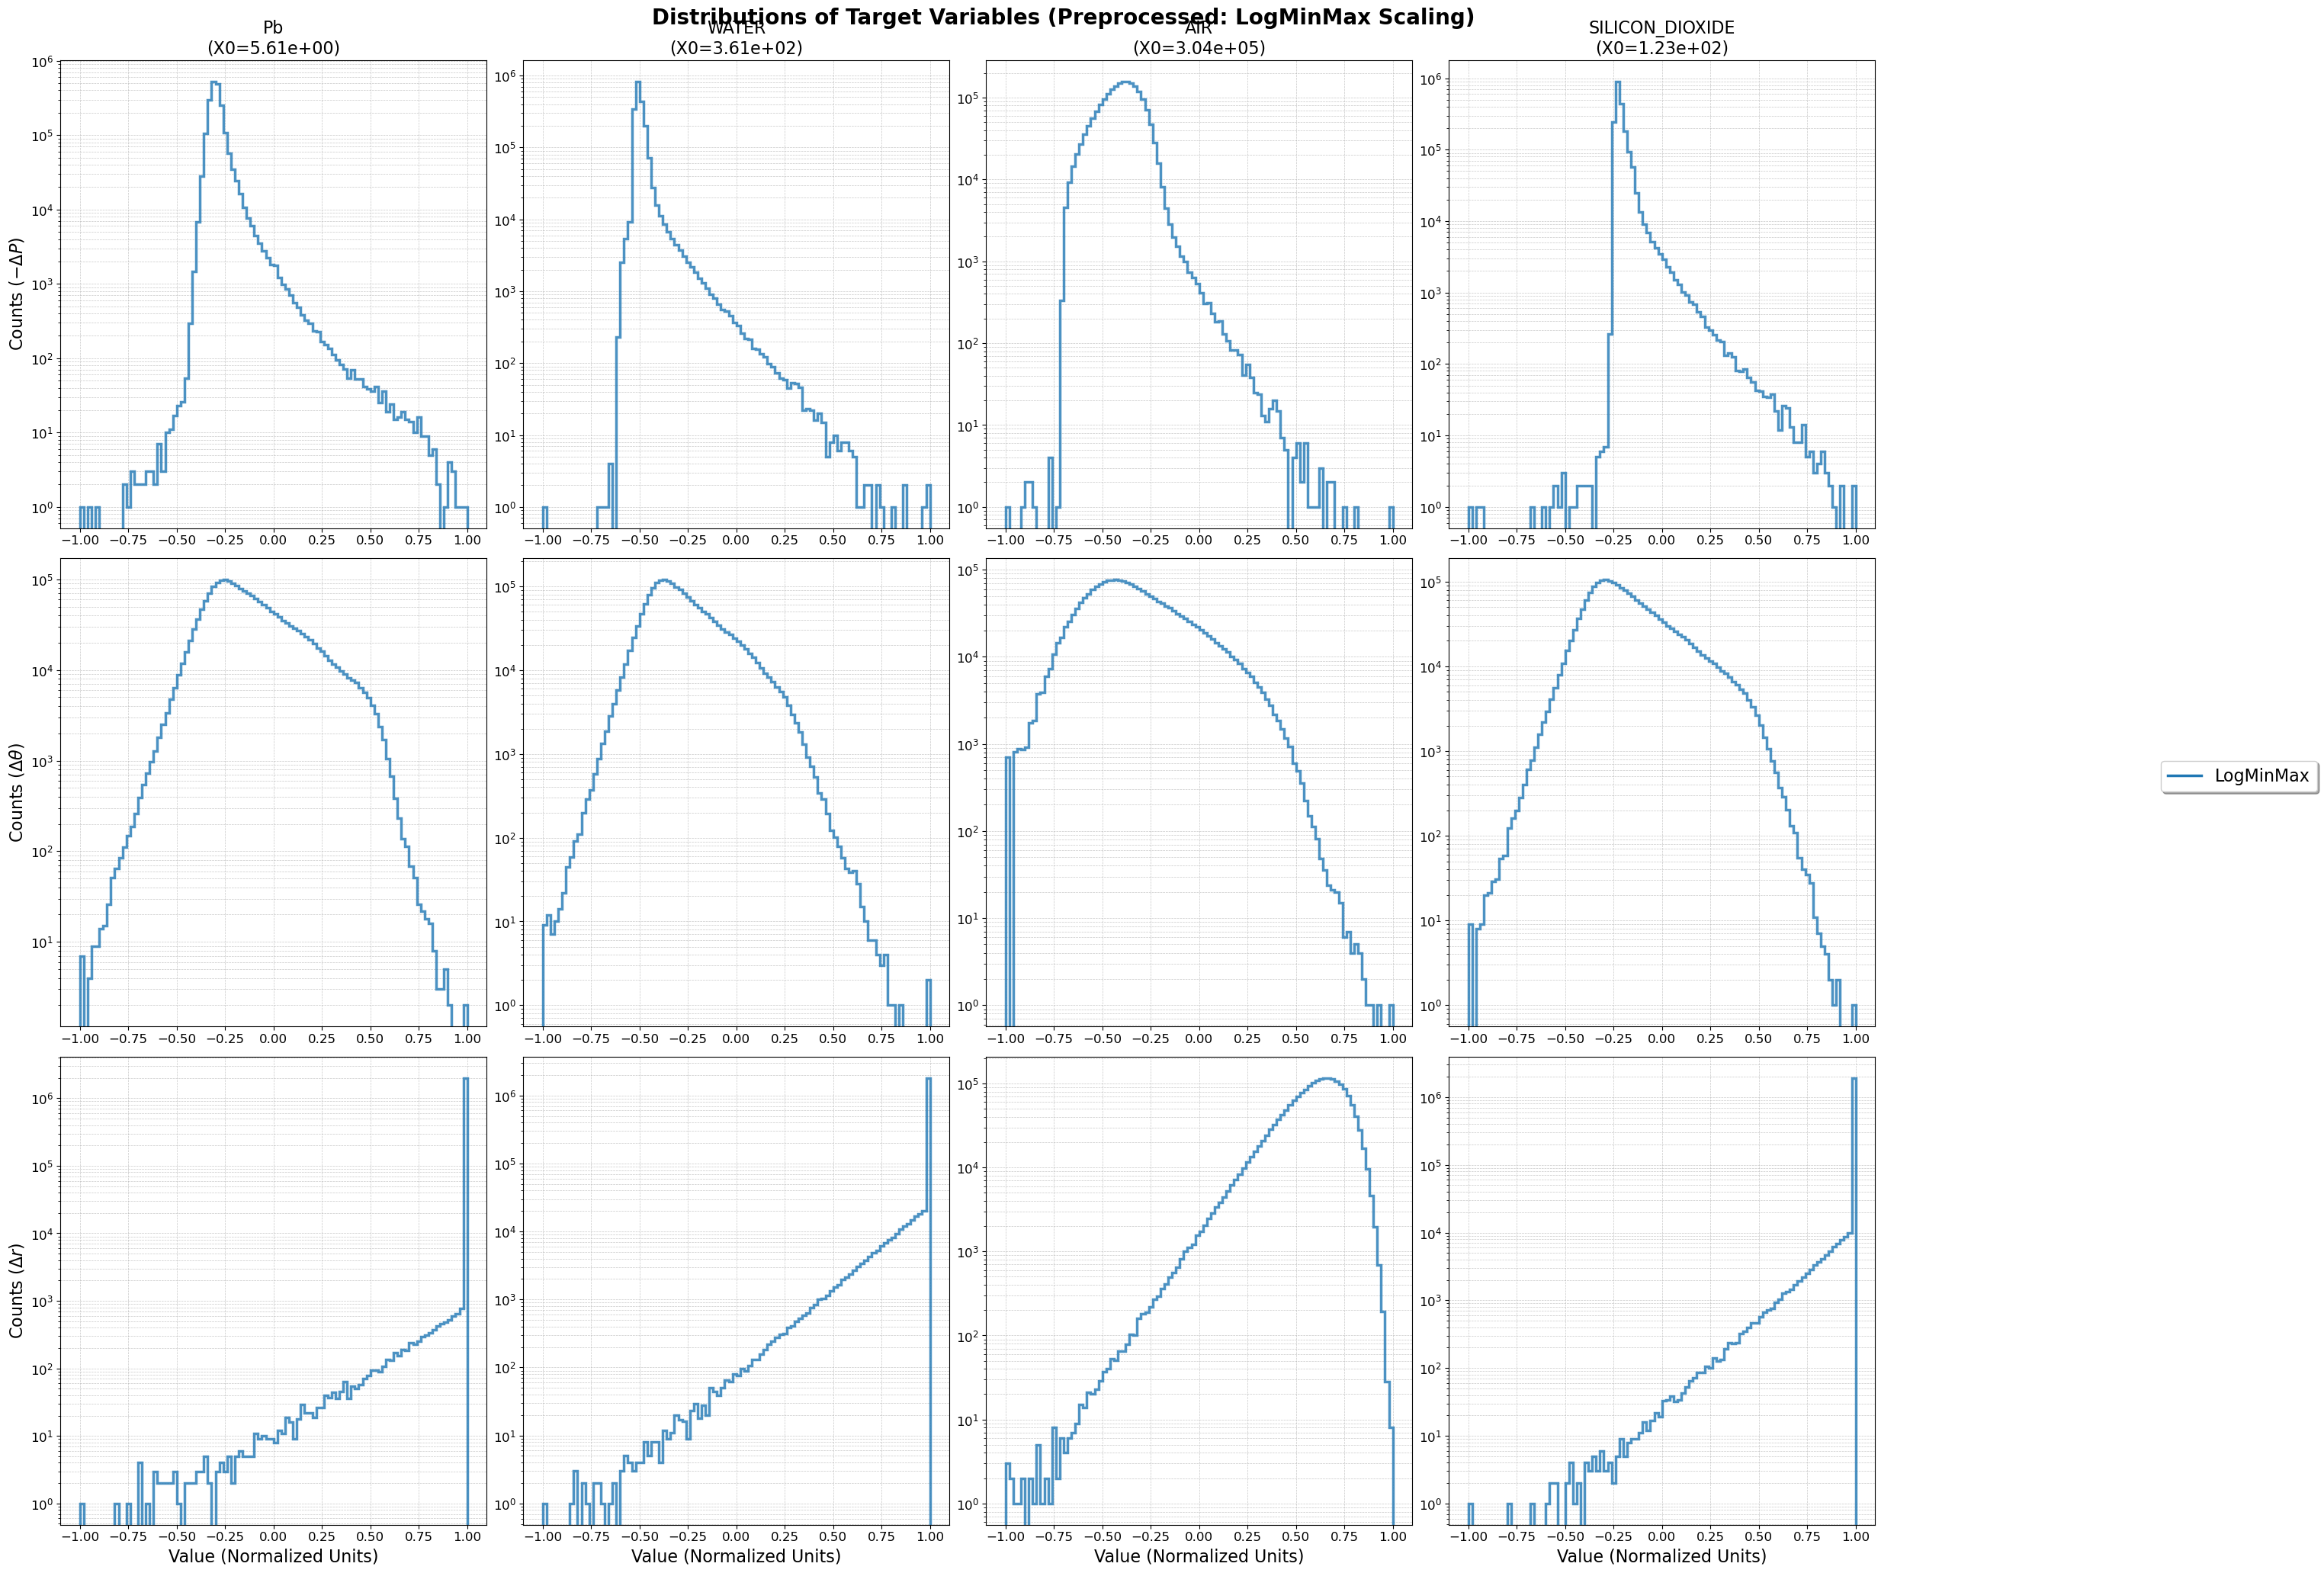


--- All plots displayed with larger scaled data plot. ---


In [5]:
# Even larger scaled plot
fig1, fig2 = plot_distributions(
    all_train_datasets, 
    X0_VALUES,
    figsize_base_original=2.5,  # Keep original small
    figsize_base_scaled=7.0     # Make scaled even larger
)